In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import current_timestamp, count, sum, when

spark = SparkSession.builder \
    .appName("FlumenData-UploadFile") \
    .master("spark://spark-master:7077") \
    .config("spark.submit.deployMode", "client") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"Master: {spark.conf.get('spark.master')}")

26/03/06 16:58:07 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.0.1
Master: spark://spark-master:7077


In [2]:
df = spark.table('social_media.facebook_data')
df.printSchema()

https://maven-central.storage-download.googleapis.com/maven2/ added as a remote repository with the name: repo-1
https://maven-central.storage-download.googleapis.com/maven2/ added as a remote repository with the name: repo-1
:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/jovyan/.ivy2.5.2/cache
The jars for the packages stored in: /home/jovyan/.ivy2.5.2/jars
org.apache.hadoop#hadoop-hdfs added as a dependency
org.datanucleus#datanucleus-api-jdo added as a dependency
org.datanucleus#datanucleus-rdbms added as a dependency
org.datanucleus#javax.jdo added as a dependency
org.springframework#spring-core added as a dependency
org.springframework#spring-jdbc added as a dependency
org.antlr#antlr4-runtime added as a dependency
org.apache.derby#derby added as a dependency
org.apache.hive#hive-metastore added as a dependency
org.apache.hive#hive-exec added as a dependency
org.apache.hive#hiv

root
 |-- post_id: long (nullable = true)
 |-- source: string (nullable = true)
 |-- post_date: boolean (nullable = true)
 |-- post_url: boolean (nullable = true)
 |-- post_text: string (nullable = true)
 |-- image_urls: string (nullable = true)
 |-- video_urls: boolean (nullable = true)
 |-- comment_count: long (nullable = true)
 |-- comment_text: string (nullable = true)
 |-- comment_reactions: long (nullable = true)
 |-- is_reply: boolean (nullable = true)
 |-- parent_comment: string (nullable = true)



In [3]:
posts_by_source = df.groupBy('source').agg(count('post_id').alias('posts'))
posts_by_source.show()

26/03/06 16:59:07 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/03/06 16:59:22 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/03/06 16:59:37 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/03/06 16:59:52 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/03/06 17:00:07 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/03/06 17:00:22 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure th

+--------------------+-----+
|              source|posts|
+--------------------+-----+
|Học viện Công ngh...|   19|
+--------------------+-----+



In [4]:
pdf = posts_by_source.toPandas()
pdf

,source,posts
0,Học viện Công nghệ Bưu chính Viễn thông - PTIT,19


Total comments by source

In [6]:
comments_by_source = df.groupBy('source').agg(sum('comment_count').alias('total_comments'))
comments_by_source.show()

+--------------------+--------------+
|              source|total_comments|
+--------------------+--------------+
|Học viện Công ngh...|           475|
+--------------------+--------------+



Plot total comments

Reply vs comment ratio

In [8]:
reply_stats = df.select(
    when(df.is_reply == True, 1).otherwise(0).alias('reply'),
    when(df.is_reply == False, 1).otherwise(0).alias('comment')
)

reply_counts = reply_stats.groupBy().sum().toPandas()
reply_counts

,sum(reply),sum(comment)
0,4,15


Plot reply ratio

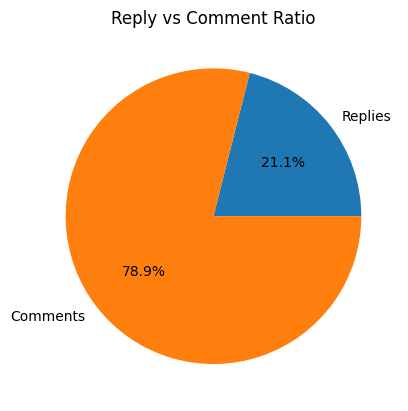

In [9]:
labels = ['Replies', 'Comments']
values = [reply_counts['sum(reply)'][0], reply_counts['sum(comment)'][0]]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Reply vs Comment Ratio')
plt.show()

In [10]:
spark.stop()
print("✓ Spark session stopped")

✓ Spark session stopped
